# Fase 5 — Backtest: custos, overfitting e fora da amostra

**Objetivo.** Transformar os retornos provisórios da Fase 4 em números que eu aceite mostrar: com custo de transação, com a curva DI real no lugar da simulada, e com os parâmetros escolhidos sem olhar o resultado.
O caminho é sempre o mesmo — pegar um número bonito e perguntar de onde ele vem: de sinal, de não pagar corretagem, ou de eu ter testado várias configurações e mostrado a melhor.
No fim sobra uma tabela de Sharpe fora da amostra e um arquivo que a Fase 6 vai usar para combinar as estratégias.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# o cwd do notebook é notebooks/, então todo caminho precisa sair da raiz do projeto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data"
sys.path.insert(0, str(RAIZ / "src"))

from moq import backtest, metrics, strategies

plt.rcParams["figure.figsize"] = (10, 4)

prices = pd.read_parquet(DATA / "processed" / "precos.parquet")
cdi = pd.read_parquet(DATA / "processed" / "cdi.parquet")["cdi"]
rets = prices.pct_change(fill_method=None).fillna(0.0)

print("preços:", prices.index.min().date(), "→", prices.index.max().date(), "|", prices.shape[1], "ativos")

preços: 2012-01-02 → 2026-09-14 | 23 ativos


## 1. A curva DI real

Na Fase 4 a estratégia de carry rodou com uma curva **simulada** — um passeio aleatório — porque eu não tinha achado a série da taxa pré de 1 ano. Os números daquela seção não diziam nada sobre o mercado. Agora a curva é real.

**De onde veio.** Do arquivo de preços e taxas diárias do Tesouro Direto, do Tesouro Transparente, salvo em `data/raw/tesouro_precos_taxas.csv`. Ele traz, para cada dia e cada título ofertado, a taxa de compra e de venda pela manhã. É dado público e já limpo na origem — não precisei ajustar nada além do formato brasileiro (`;` como separador e vírgula decimal).

**Como o título de 1 ano foi escolhido.** O Tesouro Direto não oferece um título de exatamente 1 ano: existem alguns vencimentos fixos, e a distância deles para hoje muda todo dia. Então, para cada data, filtro os **Tesouro Prefixado** (LTN, sem cupom — é a taxa pré pura, sem juros semestrais para reinvestir), mantenho os que vencem entre 180 e 730 dias e fico com o **mais próximo de 365**. É um proxy, e a seção de registro diz o quanto ele é imperfeito.

In [2]:
td = pd.read_csv(DATA / "raw" / "tesouro_precos_taxas.csv", sep=";", decimal=",", encoding="latin-1")
td.columns = [c.strip() for c in td.columns]

pre = td[td["Tipo Titulo"] == "Tesouro Prefixado"].copy()   # LTN: sem cupom, taxa pré pura
pre["base"] = pd.to_datetime(pre["Data Base"], dayfirst=True)
pre["venc"] = pd.to_datetime(pre["Data Vencimento"], dayfirst=True)
pre["prazo_dias"] = (pre["venc"] - pre["base"]).dt.days
pre = pre[(pre["prazo_dias"] > 180) & (pre["prazo_dias"] < 730)]

# por dia, o título cujo prazo mais se aproxima de 365 corridos
escolhido = pre.loc[(pre["prazo_dias"] - 365).abs().groupby(pre["base"]).idxmin()].set_index("base").sort_index()
y_1y = (escolhido["Taxa Compra Manha"] / 100).rename("y_1y")

desvio = (escolhido["prazo_dias"] - 365).abs()
print(f"curva: {y_1y.index.min().date()} → {y_1y.index.max().date()} | {len(y_1y)} dias | "
      f"{escolhido['venc'].nunique()} vencimentos diferentes usados")
print(f"distância do prazo para 365 dias: mediana {int(desvio.median())} | p90 {int(desvio.quantile(0.9))} | máx {int(desvio.max())}")

curva: 2004-12-31 → 2026-09-16 | 5419 dias | 37 vencimentos diferentes usados
distância do prazo para 365 dias: mediana 67 | p90 163 | máx 362


pré acima do CDI em 51.6% dos dias | inclinação média +0.17 p.p.

média por ano (p.p.):
Date
2012   -0.23
2013    1.13
2014    0.74
2015    0.83
2016   -0.90
2017   -1.33
2018    0.62
2019   -0.29
2020    0.41
2021    2.61
2022    0.42
2023   -1.44
2024    0.41
2025   -0.01
2026   -0.71


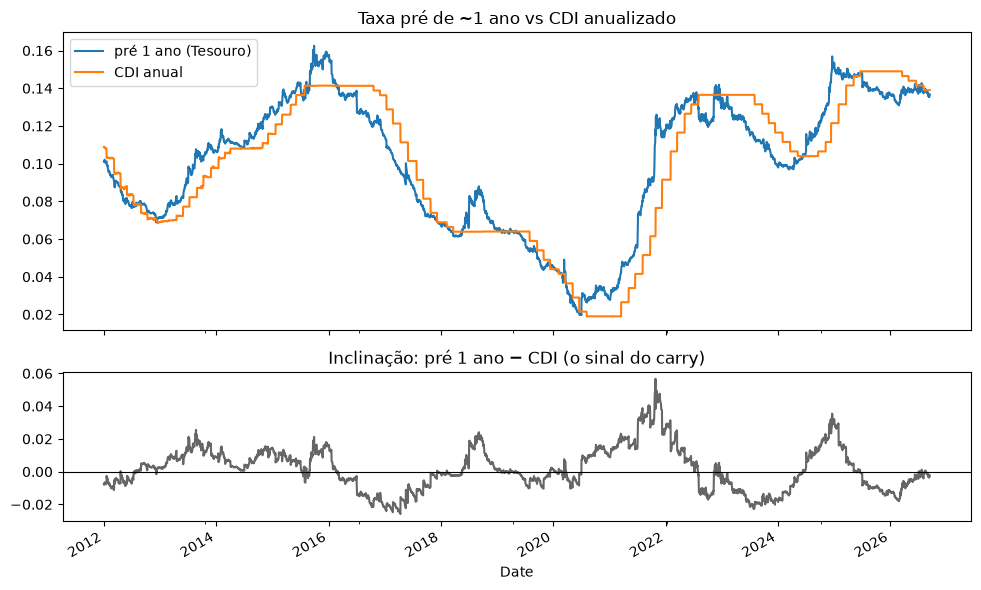

In [3]:
cdi_anual = ((1 + cdi) ** 252 - 1).where(cdi > 0).ffill()   # 6 feriados de 2017 têm CDI = 0; só no gráfico
comp = pd.DataFrame({"pré 1 ano (Tesouro)": y_1y.reindex(cdi.index).ffill(), "CDI anual": cdi_anual})
inclinacao = comp["pré 1 ano (Tesouro)"] - comp["CDI anual"]

# ax= explícito nos dois: sem isso o segundo .plot() cai no gca() e desenha por cima do primeiro
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
comp.plot(ax=ax1, title="Taxa pré de ~1 ano vs CDI anualizado")
inclinacao.plot(ax=ax2, color="0.4", title="Inclinação: pré 1 ano − CDI (o sinal do carry)")
ax2.axhline(0, color="k", lw=0.8)
fig.tight_layout()

print(f"pré acima do CDI em {(inclinacao > 0).mean():.1%} dos dias | inclinação média {100 * inclinacao.mean():+.2f} p.p.")
print("\nmédia por ano (p.p.):")
print((inclinacao.groupby(inclinacao.index.year).mean() * 100).round(2).to_string())

**O que eu vejo, e não era o que eu esperava.** A pré de 1 ano **não** fica sistematicamente acima do CDI: está acima em **51,6%** dos dias, com inclinação média de **+0,17 p.p.** Ou seja, quase não existe prêmio de prazo constante nessa ponta da curva — o que manda é expectativa de juros.

A quebra por ano mostra o padrão: a inclinação é fortemente positiva quando o mercado precifica **alta** da Selic (2021, +2,6 p.p. em média, às vésperas do ciclo de aperto) e negativa quando precifica **corte** (2016, 2017 e 2023, entre −0,9 e −1,4 p.p.).

Isso muda a leitura do carry: a estratégia não captura um prêmio de risco permanente, ela aposta que a expectativa embutida na curva está errada para cima. E o sinal por média móvel liga justamente quando a inclinação já está alta — ou seja, perto do topo do ciclo, que é quando o pré mais sofre se a alta continuar. Comparando com a Fase 4, onde a curva era um passeio aleatório independente das ações: agora a correlação baixa do carry com o resto significa alguma coisa, porque o sinal responde a ciclo de juros de verdade.

## 2. O motor: as quatro linhas da conta

Todo o backtest é isto, e vale escrever por extenso antes de esconder atrás de uma função:

$$r_t \;=\; \underbrace{\textstyle\sum_i w_{i,t}\,r_{i,t}}_{\text{bruto}} \;-\; \underbrace{\textstyle\sum_i |\Delta w_{i,t}|\cdot \tfrac{\text{bps}}{10^4}}_{\text{custo}} \;+\; \underbrace{(1 - \textstyle\sum_i |w_{i,t}|)^{+}\cdot \text{cdi}_t}_{\text{caixa}}$$

- **bruto:** o peso de cada ativo vezes o retorno dele no dia. Os pesos já vêm defasados pelo decorador `@lagged`, então nada usa o preço do próprio dia.
- **custo:** cada unidade de peso que entra ou sai paga `bps`. Trocar uma carteira long-only inteira gasta 2 (vende tudo, compra tudo).
- **caixa:** o que não está investido rende CDI. `(...)⁺` porque uma carteira long-short com Σ|w| = 1 não tem caixa sobrando — e não pode render CDI negativo.

As mesmas quatro linhas estão em `backtest.run`; aqui reproduzo na mão para conferir que a função faz o que eu penso que faz.

In [4]:
w = strategies.momentum(prices)
cost_bps = 10

gross = (w * rets).sum(axis=1)
turnover = w.diff().abs().sum(axis=1)
turnover.iloc[0] = w.iloc[0].abs().sum()          # o primeiro dia paga a entrada
cost = turnover * cost_bps / 1e4
cash = (1 - w.abs().sum(axis=1)).clip(lower=0) * cdi
net = gross - cost + cash

res = backtest.run(w, prices, cdi, cost_bps=cost_bps)
print("bate com backtest.run:", np.allclose(res.ret, net))
print(f"custo médio anual do momentum a {cost_bps} bps: {cost.mean() * 252:.2%}")

bate com backtest.run: True
custo médio anual do momentum a 10 bps: 0.53%


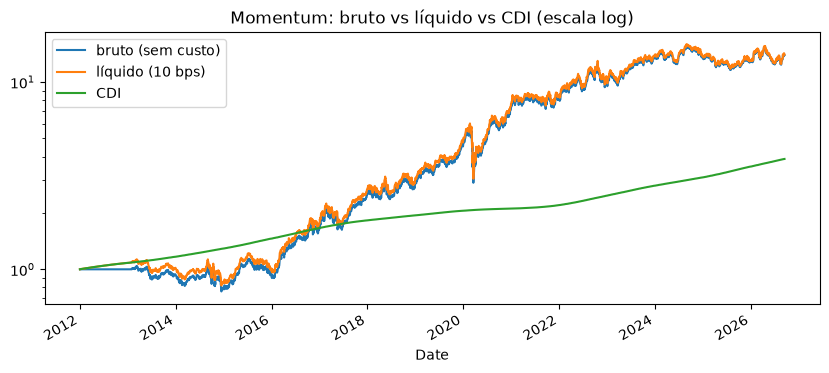

In [5]:
pd.DataFrame({"bruto (sem custo)": (1 + gross).cumprod(),
              "líquido (10 bps)": (1 + net).cumprod(),
              "CDI": (1 + cdi).cumprod()}).plot(
    logy=True, title="Momentum: bruto vs líquido vs CDI (escala log)");

**O que eu vejo.** No momentum as duas curvas quase se encostam: o custo come **0,53% ao ano**, porque a carteira só rebalanceia no fim de cada mês. Esse é o caso confortável — e é por isso que a próxima seção não olha só para o momentum.

A escala é logarítmica de propósito: em linear, o trecho final domina a figura e some a diferença dos primeiros anos.

## 3. Custo de 0, 10 e 30 bps — e o ponto onde cada estratégia morre

10 bps por unidade de peso negociada é a hipótese do projeto (corretagem + emolumentos + spread, para blue chip em ordem pequena). 30 bps é o cenário pessimista. Mas o número que realmente informa é outro: **a partir de quanto de custo a estratégia deixa de ganhar do CDI?**

Como o custo entra de forma linear no retorno, dá para resolver em vez de tentar:

$$\text{breakeven (bps)} \;=\; \frac{\overline{(\text{bruto} + \text{caixa} - \text{cdi})}}{\overline{\text{turnover}}}\times 10^4$$

In [6]:
pesos = {"momentum": strategies.momentum(prices),
         "reversao": strategies.mean_reversion(prices),
         "pares": strategies.pairs(prices, a="ITUB4", b="BBDC4")}

linhas = {}
for nome, wi in pesos.items():
    r0 = backtest.run(wi, prices, cdi, cost_bps=0)
    excesso = (r0.ret - cdi).mean()                       # excesso diário médio sem custo nenhum
    linhas[nome] = {"Sharpe 0 bps": metrics.sharpe(r0.ret, cdi),
                    "Sharpe 10 bps": metrics.sharpe(backtest.run(wi, prices, cdi, 10).ret, cdi),
                    "Sharpe 30 bps": metrics.sharpe(backtest.run(wi, prices, cdi, 30).ret, cdi),
                    "turnover/ano": r0.turnover.mean() * 252,
                    "breakeven (bps)": excesso / r0.turnover.mean() * 1e4}

custos = pd.DataFrame(linhas).T
custos.round(2)

,Sharpe 0 bps,Sharpe 10 bps,Sharpe 30 bps,turnover/ano,breakeven (bps)
momentum,0.50,0.48,0.44,5.26,238.11
reversao,0.13,-0.68,-2.30,254.51,1.61
pares,-0.60,-0.63,-0.70,2.97,-166.08


**O que eu vejo.** As três estratégias reagem ao custo de maneiras completamente diferentes, e a coluna de breakeven é a que explica:

- **Momentum — breakeven em 238 bps.** Gira 5,3 vezes por ano, então poderia pagar 24 vezes o custo assumido antes de empatar com o CDI. O Sharpe cai de 0,50 para 0,44 entre 0 e 30 bps: custo não é o problema dele.
- **Reversão — breakeven em 1,6 bps.** É o número mais importante desta fase. A estratégia gira a carteira **254 vezes por ano** e o ganho bruto dela é tão pequeno que qualquer corretagem realista já a mata: a 10 bps o Sharpe vai de +0,13 para −0,68, a 30 bps para −2,30. Não é uma estratégia cara; é uma estratégia que só existe em planilha sem custo.
- **Pares — breakeven negativo (−166 bps).** Quando o breakeven é negativo, a estratégia já perde para o CDI **de graça**: alguém teria que pagar 166 bps a ela por unidade negociada para empatar. Coerente com o par nunca ter passado no teste de cointegração.

Moral: a pergunta "quanto custa operar isso?" só tem sentido junto com "quanto de giro isso tem?". Duas estratégias com o mesmo Sharpe bruto e turnover diferente são dois negócios diferentes.

## 4. Um mercado sem sinal nenhum

Custo resolvido, sobra o outro jeito de produzir um backtest bonito: testar várias configurações e mostrar a melhor. Para medir o tamanho desse efeito, monto um mercado onde **não existe nada para capturar** — vinte ativos em passeio aleatório puro, sem tendência, sem autocorrelação, sem fator comum — e varro a grade inteira do momentum em cima dele. Todo Sharpe positivo que aparecer aqui é sorte, por construção.

In [7]:
rng = np.random.default_rng(42)
fake = pd.DataFrame(100 * np.exp(np.cumsum(rng.normal(0, 0.015, (2500, 20)), axis=0)),
                    index=pd.bdate_range("2015-01-01", periods=2500),
                    columns=[f"F{i}" for i in range(20)])
cdi0 = pd.Series(0.0, index=fake.index)

resultados = []
for lb in (63, 126, 189, 252, 378):
    for sk in (1, 5, 10, 21):            # momentum exige lookback > skip > 0: skip=0 levanta ValueError
        for top in (0.1, 0.2, 0.3):
            if not (lb > sk > 0):
                continue
            wf = strategies.momentum(fake, lookback=lb, skip=sk, top=top)
            r = backtest.run(wf, fake, cdi0, cost_bps=10).ret
            resultados.append({"lookback": lb, "skip": sk, "top": top, "sharpe": metrics.sharpe(r, cdi0)})

res_fake = pd.DataFrame(resultados).sort_values("sharpe", ascending=False)
print(f"{len(res_fake)} combinações testadas em dados SEM NENHUM SINAL")
print(f"melhor {res_fake['sharpe'].iloc[0]:.2f} | mediana {res_fake['sharpe'].median():.2f} | pior {res_fake['sharpe'].iloc[-1]:.2f}")
res_fake.head()

60 combinações testadas em dados SEM NENHUM SINAL
melhor 0.73 | mediana 0.15 | pior -0.44


,lookback,skip,top,sharpe
0,63,1,0.1,0.728685
7,63,10,0.2,0.556619
27,189,5,0.1,0.424199
3,63,5,0.1,0.416373
1,63,1,0.2,0.397125


**Em dados aleatórios, o melhor de 60 parâmetros teve Sharpe 0,73.**

A mediana das 60 combinações foi 0,15 e a pior, −0,44. A distância entre a melhor e a pior configuração — quase 1,2 de Sharpe — é **inteiramente ruído**, porque não havia nada para nenhuma delas encontrar. Quem rodasse essa grade, guardasse `lookback=63, skip=1, top=0.1` e mostrasse só essa linha teria um backtest aparentemente decente em cima de números que eu mesma sorteei.

Serve de régua para a seção anterior: o momentum na base real deu Sharpe 0,48 com 10 bps — **abaixo do melhor que o acaso produziu aqui**. A comparação não é rigorosa (períodos, número de ativos e volatilidades diferentes), mas dá a ordem de grandeza. A pergunta que todo backtest tem que responder junto com o número é: **de quantas tentativas ele é o melhor?**

## 5. Walk-forward: escolher num lugar, medir em outro

A defesa contra o que acabou de acontecer: escolher os parâmetros numa janela (**treino**) e medir na janela seguinte (**teste**), que os parâmetros nunca viram. `backtest.walk_forward` faz o laço — treina em 3 anos, testa no ano seguinte, anda um ano, repete.

**As grades, escritas antes de rodar e não mexidas depois** — quatro combinações cada:

| estratégia | grade | combinações |
|---|---|---|
| momentum | `lookback` ∈ {126, 252} × `top` ∈ {0,2; 0,3} | 4 |
| reversão | `short` ∈ {5, 10} × `threshold` ∈ {1,5; 2,0} | 4 |
| pares | `entry` ∈ {1,5; 2,0} × `window` ∈ {126, 252} | 4 |

**O warm-up** é o detalhe que quase passou batido: o teste recebe pregões anteriores para **ler** e encher as janelas, mas o `.loc[te.index]` garante que só o ano de teste entra na conta. Ler o passado não é look-ahead; avaliar o passado seria. E o tamanho do warm-up tem que vir da maior janela da grade — momentum precisa de `lookback + skip` = 273, pares precisa de 2 × `window` = 504, porque o z-score é uma rolling em cima de um beta que já é rolling. Com um warm-up de 260, pares fica com só 28% dos dias posicionado, contra 49% com 505.

In [8]:
GRADE_MOM = {"lookback": [126, 252], "top": [0.2, 0.3]}
GRADE_REV = {"short": [5, 10], "threshold": [1.5, 2.0]}
GRADE_PAR = {"entry": [1.5, 2.0], "window": [126, 252]}

oos_mom, folds_mom = backtest.walk_forward(strategies.momentum, prices, cdi, GRADE_MOM,
                                           train_years=3, test_years=1, cost_bps=10, warmup=300)
oos_rev, folds_rev = backtest.walk_forward(strategies.mean_reversion, prices, cdi, GRADE_REV, warmup=70)
oos_par, folds_par = backtest.walk_forward(lambda p, **k: strategies.pairs(p, a="ITUB4", b="BBDC4", **k),
                                           prices, cdi, GRADE_PAR, warmup=505)


def tabela_folds(folds, nome):
    t = pd.DataFrame([{"teste": f.test_start.year, "params": f.chosen,
                       "sharpe_treino": round(f.train_sharpe, 2),
                       "sharpe_teste": round(f.test_sharpe, 2)} for f in folds])
    print(f"{nome}: treino médio {t.sharpe_treino.mean():+.2f} | teste médio {t.sharpe_teste.mean():+.2f} | "
          f"teste < treino em {(t.sharpe_teste < t.sharpe_treino).sum()}/{len(t)} folds")
    return t


tabela_folds(folds_mom, "momentum")

momentum: treino médio +0.48 | teste médio +0.25 | teste < treino em 8/12 folds


,teste,params,sharpe_treino,sharpe_teste
0,2015,"{'lookback': 126, 'top': 0.3}",-0.56,-0.68
1,2016,"{'lookback': 252, 'top': 0.3}",-0.15,1.50
2,2017,"{'lookback': 252, 'top': 0.2}",0.97,1.31
3,2018,"{'lookback': 252, 'top': 0.2}",1.24,0.24
4,2019,"{'lookback': 252, 'top': 0.3}",0.61,1.80
5,2020,"{'lookback': 126, 'top': 0.2}",1.34,0.72
6,2021,"{'lookback': 252, 'top': 0.2}",0.99,0.28
7,2022,"{'lookback': 126, 'top': 0.2}",0.77,0.10
8,2023,"{'lookback': 126, 'top': 0.2}",0.56,-0.33
9,2024,"{'lookback': 252, 'top': 0.3}",0.42,-0.71


In [9]:
tabela_folds(folds_rev, "reversão")

reversão: treino médio -0.10 | teste médio -0.92 | teste < treino em 10/12 folds


,teste,params,sharpe_treino,sharpe_teste
0,2015,"{'short': 5, 'threshold': 2.0}",0.81,0.10
1,2016,"{'short': 5, 'threshold': 1.5}",0.74,-0.87
2,2017,"{'short': 5, 'threshold': 1.5}",0.09,-1.63
3,2018,"{'short': 10, 'threshold': 2.0}",0.73,-1.78
4,2019,"{'short': 10, 'threshold': 2.0}",-0.43,-0.98
5,2020,"{'short': 10, 'threshold': 1.5}",-0.54,-0.59
6,2021,"{'short': 5, 'threshold': 2.0}",-0.60,-0.54
7,2022,"{'short': 10, 'threshold': 1.5}",-0.22,-2.22
8,2023,"{'short': 5, 'threshold': 2.0}",-0.51,-1.33
9,2024,"{'short': 10, 'threshold': 2.0}",-0.70,-0.90


In [10]:
tabela_folds(folds_par, "pares")

pares: treino médio -0.30 | teste médio -0.80 | teste < treino em 9/12 folds


,teste,params,sharpe_treino,sharpe_teste
0,2015,"{'entry': 2.0, 'window': 126}",-0.50,-1.45
1,2016,"{'entry': 2.0, 'window': 252}",-0.82,-0.87
2,2017,"{'entry': 1.5, 'window': 252}",-0.39,-1.06
3,2018,"{'entry': 1.5, 'window': 252}",-0.69,-2.46
4,2019,"{'entry': 2.0, 'window': 126}",-0.01,0.44
5,2020,"{'entry': 2.0, 'window': 126}",0.37,-0.02
6,2021,"{'entry': 1.5, 'window': 126}",0.17,0.03
7,2022,"{'entry': 1.5, 'window': 126}",0.01,-0.01
8,2023,"{'entry': 1.5, 'window': 252}",0.31,-1.60
9,2024,"{'entry': 2.0, 'window': 126}",-0.69,-0.14


**O que as três tabelas dizem.**

O Sharpe cai do treino para o teste nas três estratégias — momentum **+0,48 → +0,25**, reversão **−0,10 → −0,92**, pares **−0,30 → −0,80** (médias dos 12 folds), com queda em 8, 10 e 9 dos 12 folds. É o resultado esperado, e a diferença entre as duas colunas é a medida do otimismo que a Fase 4 tinha.

**Os parâmetros escolhidos não estabilizam,** e esse é o achado mais informativo daqui. No momentum o treino pediu `lookback=252` em 7 folds e `126` em 5; `top=0.2` em 7 e `0.3` em 5. É quase cara ou coroa. Se a vantagem de um parâmetro fosse real, ele venceria de forma consistente ano após ano — alternar assim é o treino rankeando ruído, exatamente como na seção 4.

Nenhum fold tem Sharpe de treino absurdo (o maior é +1,34, em 2020), então não há sinal de vazamento de dado: o problema é falta de sinal, não look-ahead.

Dois detalhes que valem registro. O fold de 2025 em pares tem `sharpe_teste = NaN` porque a estratégia passou o ano **inteiro fora do mercado** — com tudo em caixa o retorno é exatamente o CDI, o excesso é zero e o desvio também, então o Sharpe não existe (não é zero). E o primeiro fold, 2015, é o pior de todos em momentum e pares: treinado em 2012–2014, testado no fundo da recessão.

## 6. A tabela final

As quatro séries fora da amostra, lado a lado. O carry não passa pelo `walk_forward` porque não tem grade nesta versão (`window` e `k` ficaram no padrão) — como nada nele foi escolhido olhando resultado, não há o que sair da amostra; só recorto no mesmo período dos outros.

In [11]:
r_carry = strategies.carry_returns(y_1y, cdi)     # agora com a curva real da seção 1

periodo = oos_mom.index
R_oos = pd.DataFrame({"momentum": oos_mom, "reversao": oos_rev, "pares": oos_par,
                      "carry": r_carry.reindex(periodo)}).dropna()
cdi_oos = cdi.reindex(R_oos.index)

resumo = pd.DataFrame({
    nome: {"sharpe": metrics.sharpe(r, cdi_oos),
           "ret_anual": (1 + r).prod() ** (252 / len(r)) - 1,
           "max_dd": ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()}
    for nome, r in R_oos.items()}).T

print("fora da amostra:", R_oos.index.min().date(), "→", R_oos.index.max().date(),
      f"| {len(R_oos)} pregões | datas únicas: {R_oos.index.is_unique}")
resumo.round(3)

fora da amostra: 2015-01-02 → 2026-09-14 | 2912 pregões | datas únicas: True


,sharpe,ret_anual,max_dd
momentum,0.354,0.166,-0.541
reversao,-0.790,-0.213,-0.954
pares,-0.616,0.037,-0.176
carry,-0.080,0.099,-0.025


In [12]:
# a degradação da esquerda para a direita é a história desta fase
# as três colunas usam a MESMA régua: Sharpe do excesso sobre o CDI (metrics.sharpe)
degradacao = {nome: {"Fase 4 (sem custo)": metrics.sharpe(backtest.run(wi, prices, cdi, 0).ret, cdi),
                     "amostra toda, 10 bps": metrics.sharpe(backtest.run(wi, prices, cdi, 10).ret, cdi),
                     "fora da amostra, 10 bps": metrics.sharpe(R_oos[nome], cdi_oos)}
              for nome, wi in pesos.items()}
degradacao["carry"] = {"Fase 4 (sem custo)": metrics.sharpe(r_carry, cdi),
                       "amostra toda, 10 bps": float("nan"),    # carry_returns não tem modelo de custo
                       "fora da amostra, 10 bps": metrics.sharpe(R_oos["carry"], cdi_oos)}

pd.DataFrame(degradacao).T.round(2)

,Fase 4 (sem custo),"amostra toda, 10 bps","fora da amostra, 10 bps"
momentum,0.50,0.48,0.35
reversao,0.13,-0.68,-0.79
pares,-0.60,-0.63,-0.62
carry,-0.09,NaN,-0.08


In [13]:
R_oos.corr().round(2)

,momentum,reversao,pares,carry
momentum,1.00,0.15,-0.10,0.03
reversao,0.15,1.00,-0.01,0.01
pares,-0.10,-0.01,1.00,0.02
carry,0.03,0.01,0.02,1.00


In [14]:
R_oos.to_parquet(DATA / "processed" / "retornos_oos.parquet")
conferindo = pd.read_parquet(DATA / "processed" / "retornos_oos.parquet")
print("salvo:", conferindo.shape, list(conferindo.columns), "| igual ao que está na memória:", conferindo.equals(R_oos))

salvo: (2912, 4) ['momentum', 'reversao', 'pares', 'carry'] | igual ao que está na memória: True


**A degradação, uma frase por estratégia.**

- **Momentum (0,50 → 0,48 → 0,35):** cai pouco com custo, porque gira uma vez por mês; o resto da queda é a escolha de parâmetros deixando de ser feita com o resultado na mão. Sobra Sharpe positivo, mas de tamanho indistinguível do melhor que o acaso produziu na seção 4 (0,73).
- **Reversão (0,13 → −0,68 → −0,79):** praticamente toda a queda acontece na segunda coluna — é o breakeven de 1,6 bps cobrando o preço. Fora da amostra piora mais um pouco.
- **Pares (−0,60 → −0,63 → −0,62):** não degradou porque não havia o que degradar. O par ITUB4/BBDC4 nunca passou no teste de cointegração (p = 0,43) e perde nas três colunas de forma consistente.
- **Carry (−0,09 → — → −0,08):** é o único sem parâmetro escolhido, e por isso o único cujo número praticamente não muda: nada foi ajustado, nada tinha para desajustar. Rende 9,9% ao ano com drawdown de 2,5%, mas fica abaixo do CDI — e o CDI é o benchmark.

**As correlações continuam baixas fora da amostra:** a maior em módulo é momentum × reversão (0,15), e a única outra acima de 0,05 é momentum × pares (−0,10). A tese do projeto — combinar estratégias pouco correlacionadas reduz risco — sobrevive ao teste. O que não sobrevive é a expectativa de ter quatro retornos positivos para combinar: fora da amostra, só o momentum ganha do CDI.

**O que vai para a Fase 6:** `data/processed/retornos_oos.parquet`, com as quatro séries de 2015 a 2026, todas fora da amostra e já com 10 bps de custo.

## 7. Registro

**As grades.** Quatro combinações cada, fixadas antes de rodar e não alteradas depois:

| estratégia | grade | combinações |
|---|---|---|
| momentum | `lookback` ∈ {126, 252} × `top` ∈ {0,2; 0,3} | 4 |
| reversão | `short` ∈ {5, 10} × `threshold` ∈ {1,5; 2,0} | 4 |
| pares | `entry` ∈ {1,5; 2,0} × `window` ∈ {126, 252} | 4 |
| carry | nenhuma — `window=252`, `k=1.0` no padrão | 1 |

Os demais parâmetros ficaram no padrão da Fase 4 (`skip=21`, `long=60`, `exit=0.5`, `stop=4.0`). São 12 avaliações de treino por estratégia por fold — grade pequena de propósito: quanto maior a grade, maior o melhor Sharpe que o acaso entrega, e a seção 4 mostra o tamanho disso.

**O custo assumido: 10 bps** por unidade de peso negociada, cobrados sobre Σ|Δw| de cada dia. Cobrem corretagem, emolumentos e metade do spread para uma blue chip em ordem pequena. 30 bps aparece como cenário pessimista, e o breakeven de cada estratégia está na seção 3.

**A fonte da curva DI:** `data/raw/tesouro_precos_taxas.csv`, preços e taxas diárias do Tesouro Direto (Tesouro Transparente). A série de 1 ano é o Tesouro Prefixado com prazo mais próximo de 365 dias corridos, entre 180 e 730, pela taxa de compra da manhã. A série derivada fica em `data/processed/curva_pre_1y.parquet`.

### O que ainda é otimista

Mesmo depois de custo e walk-forward, estes números continuam sendo um teto. Em ordem de gravidade:

1. **Viés de sobrevivência.** O universo são 23 ações escolhidas hoje, entre as que continuam grandes e líquidas. Quem quebrou, foi comprada ou encolheu nunca entrou na amostra — e seria justamente o prejuízo. O erro tem sempre o mesmo sinal, não sai com mais dados e contamina principalmente o momentum, que é a única estratégia que sobrou com Sharpe positivo. Consertar exige reconstruir o universo ano a ano com o COTAHIST da B3.
2. **A perna vendida dos pares não paga aluguel.** Vender uma ação exige alugá-la, e o aluguel custa de meio a vários por cento ao ano, variando por papel e por época — em papel difícil de encontrar, muito mais. Nada disso está no modelo: o custo aqui é só Σ|Δw| × bps, que trata compra e venda igual. Vale para os pares e para a perna curta da reversão, e ambos pioram.
3. **Impacto de mercado.** O custo é linear e independente do tamanho: 10 bps por unidade de peso, seja a carteira de R$ 10 mil ou de R$ 100 milhões. Na vida real a ordem grande anda contra o próprio preço, e o impacto cresce com o tamanho relativo ao volume negociado — que esta base nem tem, já que só guardamos fechamento. A reversão, que gira 254 vezes por ano, é a mais exposta.
4. **O CDI alinhado é levemente subestimado** (12,99% contra 13,04% em 2023, pela diferença entre o calendário da B3 e os dias em que o CDI rende). O erro é pequeno, mas empurra sempre no mesmo sentido: a favor da estratégia, contra o benchmark.
5. **Um só par, um só ativo de carry, um só universo.** Nada aqui foi testado em outro recorte — outro par de bancos, outro conjunto de ações, outro país. Um resultado que só existe numa configuração é uma hipótese, não uma conclusão.